# Preliminary analysis antibody panel 1

## Gather metadata

### Experimental design metadata
Each plate was run with a single antibody panel (1 or 2)
| Antibody panel | DAPI | CF488A        | CF568        | CF640        |
| -------------- | ---- | ------------- | ------------ | ------------ |
| 1              | DAPI | TOMM20-CF488A | EEA1         | LAMP1        |
| 2              | DAPI | RAB11A        | GM130-CF568  | TUJ1-CF640   |

In [1]:
import pandas as pd

experimental_design = {
    "Panel": [1, 2],
    "DAPI": ["DAPI", "DAPI"],
    "Alexa 488": ["TOMM20", "RAB11A"],
    "Alexa 568": ["EEA1", "GM130"],
    "Alexa 647": ["LAMP1", "TUJ1"],
}

experimental_design = pd.DataFrame(experimental_design)

In [2]:
# consider adding a new column that representes the organelle targeted by the antibody

experimental_design = experimental_design.melt(
    id_vars=["Panel"], 
    value_vars=["DAPI", "Alexa 488", "Alexa 568", "Alexa 647"],
    var_name="Channel_name",
    value_name="Stain")

In [3]:
print(experimental_design)

   Panel Channel_name   Stain
0      1         DAPI    DAPI
1      2         DAPI    DAPI
2      1    Alexa 488  TOMM20
3      2    Alexa 488  RAB11A
4      1    Alexa 568    EEA1
5      2    Alexa 568   GM130
6      1    Alexa 647   LAMP1
7      2    Alexa 647    TUJ1


### Opera Phenix metadata

#### Define metadata files

In [4]:
# Define relevant dictionaries for metatdata

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Define pseudocolor mapping rules - helpful to generate images on the fly
pseudocolor_map = {
    "DAPI": "blue",
    "Brightfield": "gray",
    "Alexa 488": "green",
    "Alexa 568": "red",
    "Alexa 647": "magenta"
}

# Define pseudocolor mapping rules for matplotlib - helpful to generate images on the fly
mpl_colormaps = {
    "blue": LinearSegmentedColormap.from_list("black_blue", [(0, 0, 0), (0, 0, 1)]),
    "green": LinearSegmentedColormap.from_list("black_green", [(0, 0, 0), (0, 1, 0)]),
    "red": LinearSegmentedColormap.from_list("black_red", [(0, 0, 0), (1, 0, 0)]),
    "magenta": LinearSegmentedColormap.from_list("black_magenta", [(0, 0, 0), (1, 0, 1)]),
    "gray": LinearSegmentedColormap.from_list("black_gray", [(0, 0, 0), (1, 1, 1)])
}

In [5]:
from pathlib import Path
import xml.etree.ElementTree as ET

experiment_name = "028ebee9-afaf-4ff8-b435-af11714285dc"

base_path = Path("/data/CARDPB2/iNDI/Production")
experiment_path = base_path / experiment_name

experiment_xml_file = next(experiment_path.glob("*.xml"), None)

experiment_img_dir = experiment_path / "images"

index_xml = next((experiment_path / "index").glob("*.xml"), None)

In [6]:
import xml.etree.ElementTree as ET
from pathlib import Path
import pandas as pd

tree = ET.parse(experiment_xml_file)
OF_dir = Path(experiment_img_dir)
index_tree = ET.parse(index_xml)

root = tree.getroot()

# Namespace mapping
ns = {'h': '43B2A954-E3C3-47E1-B392-6635266B0DD3/HarmonyV7'} # I believe this is consistent between all experiments

# Find elements
measurement_id = root.find('h:MeasurementID', ns).text
date = root.find('h:Date', ns).text
plate = root.find('h:InitialPlateName', ns).text

print("Measurement ID:", measurement_id)
print("Date:", date)
print("Plate:", plate)

root = index_tree.getroot()

# Find elements
plate_id = root.find('.//h:PlateID', ns).text
x_res = float(root.find('.//h:ImageResolutionX', ns).text) * 1e6
y_res = float(root.find('.//h:ImageResolutionY', ns).text) * 1e6

print("Plate:", plate_id)
print(f"X resolution: {x_res} µm")
print(f"Y resolution: {y_res} µm")

channels = []

# Find the Map element that contains channel info entries
for map_el in root.findall(".//h:Map", ns):
    # Check first entry if it has a ChannelName child
    first_entry = map_el.find("h:Entry", ns)
    if first_entry is not None and first_entry.find("h:ChannelName", ns) is not None:
        # Found the Map with channel entries
        for entry in map_el.findall("h:Entry", ns):
            ch_id = entry.attrib.get("ChannelID")
            ch_name = entry.find("h:ChannelName", ns).text
            ch_type = entry.find("h:ChannelType", ns).text if entry.find("h:ChannelType", ns) is not None else None
            excitation = entry.find("h:MainExcitationWavelength", ns).text if entry.find("h:MainExcitationWavelength", ns) is not None else None
            emission = entry.find("h:MainEmissionWavelength", ns).text if entry.find("h:MainEmissionWavelength", ns) is not None else None

            channels.append({
                "ChannelID": int(ch_id) if ch_id is not None else None,
                "Channel_name": ch_name,
                "Type": ch_type,
                "Excitation_nm": excitation,
                "Emission_nm": emission
            })
        break  

# Convert to DataFrame
channel_df = pd.DataFrame(channels).sort_values('ChannelID').reset_index(drop=True)
print(channel_df)

channel_df["Pseudocolor"] = channel_df["Channel_name"].map(pseudocolor_map).fillna("gray")
channel_df["MPL_colormap"] = channel_df["Pseudocolor"].str.lower().map(mpl_colormaps)
channel_df["Measurement_ID"] = measurement_id
channel_df["Measurement_date"] = date
channel_df["Plate_ID"] = plate_id
channel_df["res_x"] = x_res
channel_df["res_y"] = y_res

print(channel_df)

Measurement ID: 028ebee9-afaf-4ff8-b435-af11714285dc
Date: 2026-02-15T16:35:37.9513374-05:00
Plate: 260215_212938-V
Plate: INDIEC006
X resolution: 0.09418670872212731 µm
Y resolution: 0.09418670872212731 µm
   ChannelID Channel_name          Type Excitation_nm Emission_nm
0          1         DAPI  Fluorescence           375         456
1          2    Alexa 647  Fluorescence           640         706
2          3    Alexa 488  Fluorescence           488         522
3          4    Alexa 568  Fluorescence           561         599
   ChannelID Channel_name          Type Excitation_nm Emission_nm Pseudocolor  \
0          1         DAPI  Fluorescence           375         456        blue   
1          2    Alexa 647  Fluorescence           640         706     magenta   
2          3    Alexa 488  Fluorescence           488         522       green   
3          4    Alexa 568  Fluorescence           561         599         red   

                                        MPL_colormap  \
0

## Plate summary

In [7]:
import re
import pandas as pd

# Collect all .tiff files
files = sorted([f for f in OF_dir.rglob('*') if f.suffix.lower() in ['.tiff']])

# Define a function to parse the filename
def parse_filename(name):
    match = re.match(r"r(\d+)c(\d+)f(\d+)p(\d+)-ch(\d+)t(\d+)", name)
    if match:
        return [int(g) for g in match.groups()]
    else:
        return [None] * 6  # Fallback if filename doesn't match

# Create a DataFrame with full path and relative subdirectory
df = pd.DataFrame({
    'filepath': files,
    'filename': [f.name for f in files], 
    'subdirectory': [f.parent.relative_to(OF_dir) for f in files]
})

# Extract metadata from filenames
df[['Row', 'Column', 'Frame', 'Plane', 'ChannelID', 'Time']] = df['filename'].apply(
    lambda x: pd.Series(parse_filename(x))
)

print(df.head())

                                            filepath  \
0  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
1  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
2  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
3  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
4  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   

                    filename subdirectory  Row  Column  Frame  Plane  \
0  r02c03f01p01-ch01t01.tiff       r02c03    2       3      1      1   
1  r02c03f01p01-ch02t01.tiff       r02c03    2       3      1      1   
2  r02c03f01p01-ch03t01.tiff       r02c03    2       3      1      1   
3  r02c03f01p01-ch04t01.tiff       r02c03    2       3      1      1   
4  r02c03f02p01-ch01t01.tiff       r02c03    2       3      2      1   

   ChannelID  Time  
0          1     1  
1          2     1  
2          3     1  
3          4     1  
4          1     1  


In [8]:
merged_ChannelID_df = pd.merge(df, channel_df, on="ChannelID")
merged_ChannelID_df["Panel"] = 1
print(merged_ChannelID_df)

                                                filepath  \
0      /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
1      /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
2      /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
3      /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
4      /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
...                                                  ...   
29395  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
29396  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
29397  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
29398  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
29399  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   

                        filename subdirectory  Row  Column  Frame  Plane  \
0      r02c03f01p01-ch01t01.tiff       r02c03    2       3      1      1   
1      r02c03f01p01-ch02t01.tiff       r02c03    2       3      1      1   
2      r02c03f01p01-ch03t01.tiff       r02c03    2 

In [9]:
summary = {
    "wells": merged_ChannelID_df[['Row', 'Column']].drop_duplicates().shape[0],
    "channels": merged_ChannelID_df['ChannelID'].nunique(),
    "z_planes": merged_ChannelID_df['Plane'].nunique(),
    "frames": merged_ChannelID_df['Frame'].nunique(),
    "timepoints": merged_ChannelID_df['Time'].nunique(),
}

print(summary)

print(f"""
Experiment ID: {measurement_id}
Plate ID: {plate}
Wells imaged: {summary["wells"]}
Frames per well: {summary["frames"]}
Channels per image: {summary["channels"]}
Z-slices per image: {summary["z_planes"]}
Timepoints per image: {summary["timepoints"]}
""")

{'wells': 210, 'channels': 4, 'z_planes': 1, 'frames': 35, 'timepoints': 1}

Experiment ID: 028ebee9-afaf-4ff8-b435-af11714285dc
Plate ID: 260215_212938-V
Wells imaged: 210
Frames per well: 35
Channels per image: 4
Z-slices per image: 1
Timepoints per image: 1



In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

antigens = {
    "GM130": "Golgi",
    "LAMP1": "Lysosome",
    "G3BP1": "Stress granule",
    "EEA1": "Endosome",
    "TOMM20": "Mitochondria",
    "TUBB3": "Microtubules",
    "TGN46": "Golgi",
    "MAP2": "Microtubules",
    "TUJ1": "Microtubules",
    "DAPI": "Nuclei"
}

antigen_keys = list(antigens.keys())
pattern = r"\b(" + "|".join(re.escape(k) for k in antigen_keys) + r")\b"

matched_antigen = experimental_design["Stain"].str.extract(pattern, flags=re.IGNORECASE)[0]

experimental_design["Structure"] = matched_antigen.str.upper().map({k.upper(): v for k, v in antigens.items()})
experimental_design["Structure"] = experimental_design["Structure"].fillna("Unknown")

print(experimental_design.columns)
print(merged_ChannelID_df.columns)

## merge to merged_ChannelID_df by panel and channel name to make samplesheet

samplesheet = pd.merge(merged_ChannelID_df, experimental_design, on=["Channel_name", "Panel"])
print(samplesheet.head)

Index(['Panel', 'Channel_name', 'Stain', 'Structure'], dtype='object')
Index(['filepath', 'filename', 'subdirectory', 'Row', 'Column', 'Frame',
       'Plane', 'ChannelID', 'Time', 'Channel_name', 'Type', 'Excitation_nm',
       'Emission_nm', 'Pseudocolor', 'MPL_colormap', 'Measurement_ID',
       'Measurement_date', 'Plate_ID', 'res_x', 'res_y', 'Panel'],
      dtype='object')
<bound method NDFrame.head of                                                 filepath  \
0      /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
1      /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
2      /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
3      /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
4      /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
...                                                  ...   
29395  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
29396  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
29397  /data/CARDPB2/iNDI/Production/028ebee9-af

## Open matching nuclei feature file
Expected that nucleus segmentation is complete already

In [11]:
import pandas as pd
from pathlib import Path

nuclei_features_files = Path('/data/CARDPB2/iNDI/Production/nucleus_segmentation_result')

file = next(f for f in nuclei_features_files.iterdir() if experiment_name in f.name)
nuclei_features = pd.read_csv(file)

nuclei_features["experiment_name"] = experiment_name

print(nuclei_features.head())

   label     area  mean_intensity  max_intensity  min_intensity  \
0      1   4939.0     3642.956266         6248.0         1735.0   
1      2   9671.0     6493.838693        27547.0         1174.0   
2      3   6054.0     4234.435580        10726.0          883.0   
3      5   8794.0      960.669093         1456.0          608.0   
4      6  12435.0     4042.183353        13133.0         1411.0   

   std_intensity   centroid-0   centroid-1  eccentricity  solidity  \
0     891.057838    24.399069  1195.013768      0.842756  0.983277   
1    3302.626429   409.897839  1343.616379      0.729209  0.970302   
2    1676.650264   796.202346   620.880410      0.661181  0.967247   
3     197.895244   964.316579    67.486354      0.575190  0.969036   
4    1584.921888  1000.838118   721.246321      0.713834  0.961122   

    perimeter  feret_diameter_max  orientation  major_axis_length  \
0  293.338095          112.294256    -1.438186         110.444215   
1  395.688384          137.440896     

### Test with a single image

## Mask organelles around nuclear area

### Golgi mask

In [12]:
import numpy as np
from scipy.stats import norm
from scipy.ndimage import distance_transform_edt, gaussian_laplace, binary_fill_holes
from skimage import filters, morphology
from skimage.filters import threshold_triangle, threshold_otsu
from skimage.morphology import remove_small_objects, erosion, dilation, ball
from skimage.morphology import disk as morph_disk
from skimage.measure import label

def process_golgi_mask(image,
                       intensity_scaling_param = [9, 19],
                       blur_sigma = 1,
                       log_sigma = 1.6,
                       log_cutoff = 0.02,
                       low_thresh_minArea = 1200,
                       minArea = 10,
                       thin_dist = 1):
    
    """

    Golgi segmentation modeled after Allen Institute for Cell Science's Allen Cell and Structure Segmenter, 
    this was originally built for 3D images but I have made some modifications for 2D images.

    Parameter:
    -------------
    image: np.ndarray
        the image to be segmented, this should be the nuclear masked image and the only the channel that 
        features the Golgi stain. 
    intensity_scaling_param: list of int
        Cutoffs for contrast stretching. 
    blur_sigma: float
        Standard deviation for Gaussian blur applied before further processing. Helps reduce noise.
    log_sigma: float
        Sigma value for the Laplacian of Gaussian (LoG) filter, which enhances blob-like features 
        typical of Golgi structures.
    log_cutoff: float
        Threshold applied after LoG filtering to create a binary mask. Pixels with LoG response 
        above this value are kept.
    minArea: int
        Minimum area (in pixels) for objects to keep after segmentation. Smaller objects are removed 
        as likely noise or artifacts.
    thin_dist: int
        Radius used in morphological thinning or safe-zone distance thresholding.

    """

    # Normalize image
    m, s = norm.fit(image)
    stretch_min = max(m - intensity_scaling_param[0] * s, image.min())
    stretch_max = min(m + intensity_scaling_param[1] * s, image.max())
    image_clip = np.clip(image, stretch_min, stretch_max)
    image_norm = (image_clip - stretch_min) / (stretch_max - stretch_min + 1e-12)

    # Blur image
    blurred = filters.gaussian(image_norm, sigma=blur_sigma)

    # Generate a thinned golgi mask via thresholding 
    thresh = threshold_triangle(blurred)

    img_low_thresh = blurred > thresh
    img_low_thresh = remove_small_objects(img_low_thresh, min_size=low_thresh_minArea, connectivity=1)
    img_low_thresh = dilation(img_low_thresh, footprint=morph_disk(2))

    img_high_thresh = np.zeros_like(img_low_thresh)
    lab_low, num_obj = label(img_low_thresh, return_num=True, connectivity=1)

    for idx in range(num_obj):
        single_obj = lab_low == (idx + 1)
        local_otsu = threshold_otsu(blurred[single_obj > 0])
        img_high_thresh[np.logical_and(blurred > local_otsu * 0.98, single_obj)] = 1

    mask = np.zeros_like(img_high_thresh)
    skeleton = morphology.medial_axis(img_high_thresh > 0)
    dist = distance_transform_edt(skeleton == 0)
    mask = dist > 1 + 1e-5
    thinned = np.logical_xor(img_high_thresh > 0, erosion(img_high_thresh > 0, morph_disk(thin_dist)))

    skele_mask = np.where(np.logical_and(mask, thinned), 0, img_high_thresh)

    # Identify blobs
    log = -1 * (log_sigma**2) * gaussian_laplace(blurred, sigma=log_sigma)
    log_mask = log > log_cutoff

    # combine the two masks
    mask = np.logical_or(log_mask, skele_mask)

    golgi_mask = remove_small_objects(mask > 0, min_size=minArea, connectivity=1)
    golgi_mask = binary_fill_holes(golgi_mask)

    return golgi_mask

### Lysosome mask

In [13]:
import numpy as np
from scipy.stats import norm
from scipy.ndimage import gaussian_laplace, binary_fill_holes
from skimage import filters
from skimage.morphology import remove_small_objects

def process_lysosome_mask(image,
                          intensity_scaling_param = [3, 19],
                          blur_sigma = 1,
                          log_params = ((5.0, 0.09), (2.5, 0.07), (1.0, 0.01)),
                          vesselness_sigma = [1],
                          vesselness_cutoff = 0.15,
                          min_area = 15):
    """
    Lysosome segmentation for 2D single-cell images, adapted to mirror the style of
    the Allen Cell & Structure Segmenter-inspired Golgi routine.

    Parameters
    ----------
    image : np.ndarray
        Single-channel image to segment (ideally already cropped/masked to a single cell).
    intensity_scaling_param : list[int]
        Cutoffs (lower_sigma_mult, upper_sigma_mult) for contrast stretching around the
        fitted normal mean (m) and std (s): [3, 19] by default.
    blur_sigma : float
        Gaussian blur sigma applied before LoG/vesselness to reduce noise.
    log_params : tuple[tuple[float, float], ...]
        Sequence of (sigma, cutoff) pairs for multi-scale Laplacian of Gaussian blob detection.
        A pixel is kept if any scale exceeds its cutoff.
    vesselness_sigmas : tuple[float, ...]
        Scales for Frangi vesselness (used to capture elongated lysosomal structures).
    vesselness_cutoff : float
        Threshold applied to the Frangi response.
    min_area : int
        Minimum area (in pixels) for keeping segmented objects.

    Returns
    -------
    np.ndarray (bool)
        Binary mask of lysosome regions.
    """

    # Normalize image by robust z-windowing with contrast stretch
    m, s = norm.fit(image.ravel())
    stretch_min = max(m - intensity_scaling_param[0] * s, image.min())
    stretch_max = min(m + intensity_scaling_param[1] * s, image.max())
    image_clip = np.clip(image, stretch_min, stretch_max)
    image_norm = (image_clip - stretch_min) / (stretch_max - stretch_min + 1e-12)

    # Denoise
    blurred = filters.gaussian(image_norm, sigma=blur_sigma)

    # Multi-scale LoG blob mask
    log_masks = []
    for sigma, cutoff in log_params:
        log_resp = -1.0 * (sigma ** 2) * gaussian_laplace(blurred, sigma=sigma)
        log_masks.append(log_resp > cutoff)
    log_mask = np.logical_or.reduce(log_masks) if log_masks else np.zeros_like(image_norm, dtype=bool)

    # Frangi vesselness (captures small elongated features)
    vessel = filters.frangi(blurred, sigmas=vesselness_sigma)
    vessel_mask = vessel > vesselness_cutoff

    # Combine cues
    combined = np.logical_or(log_mask, vessel_mask)

    # Clean up: fill holes, remove tiny specks
    filled = binary_fill_holes(combined)
    lysosome_mask = remove_small_objects(filled, min_size=min_area, connectivity=1)

    return lysosome_mask

### Endosome mask

In [14]:
import numpy as np
from scipy.stats import norm
from scipy.ndimage import gaussian_laplace, binary_fill_holes
from skimage import filters
from skimage.morphology import remove_small_objects

def process_endosome_mask(image,
                          intensity_scaling_param = [3, 19],
                          blur_sigma = 1.0,
                          log_params = ((1.0, 0.03),),  # (sigma, cutoff) pairs; endosomes ~ small blobs
                          min_area = 3):
    """
    Endosome segmentation for 2D single-cell images.

    Parameters
    ----------
    image : np.ndarray
        Single-channel image to segment (ideally cropped/masked to a single cell).
    intensity_scaling_param : list[int]
        Contrast stretch around fitted normal (m ± k*s). Default [3, 19].
    blur_sigma : float
        Gaussian blur sigma before LoG.
    log_params : tuple[tuple[float, float], ...]
        One or more (sigma, cutoff) pairs for Laplacian-of-Gaussian blob detection.
    min_area : int
        Minimum connected area (pixels) to keep.

    Returns
    -------
    np.ndarray (bool)
        Binary mask of endosome.
    """

    # Normalize (robust z-window + safe denom)
    m, s = norm.fit(image.ravel())
    stretch_min = max(m - intensity_scaling_param[0] * s, image.min())
    stretch_max = min(m + intensity_scaling_param[1] * s, image.max())
    image_clip = np.clip(image, stretch_min, stretch_max)
    image_norm = (image_clip - stretch_min) / (stretch_max - stretch_min + 1e-12)

    # Denoise
    blurred = filters.gaussian(image_norm, sigma=blur_sigma)

    # LoG blob detection (union over scales)
    log_masks = []
    for sigma, cutoff in log_params:
        log_resp = -1.0 * (sigma ** 2) * gaussian_laplace(blurred, sigma=sigma)
        log_masks.append(log_resp > cutoff)
    log_mask = np.logical_or.reduce(log_masks) if log_masks else np.zeros_like(image_norm, dtype=bool)

    # Fill small holes & remove tiny specks
    filled = binary_fill_holes(log_mask)
    endosome_mask = remove_small_objects(filled, min_size=min_area, connectivity=1)

    return endosome_mask


### Mitochondria mask

In [15]:
import numpy as np
from scipy.stats import norm
from scipy.ndimage import gaussian_laplace, binary_fill_holes
from skimage import filters
from skimage.morphology import remove_small_objects


def process_mitochondria_mask(image,
                              intensity_scaling_param = [3.5, 15],
                              blur_sigma = 1.0,
                              log_params = ((5.0, 0.09), (2.5, 0.07), (1.0, 0.01)),
                              vesselness_sigmas = (1.5,),
                              vesselness_cutoff = 0.16,
                              black_ridges = False,
                              min_area = 10,
                              fill_holes = False):
    """
    Mitochondria segmentation for 2D single-cell images.

    Parameters
    ----------
    image : np.ndarray
        Single-channel image to segment (ideally cropped/masked to a single cell).
    intensity_scaling_param : list[float]
        Contrast stretch around fitted normal (m ± k*s). Default [3.5, 15].
    blur_sigma : float
        Gaussian blur sigma prior to LoG / vesselness.
    log_params : tuple[tuple[float, float], ...]
        One or more (sigma, cutoff) pairs for Laplacian-of-Gaussian blob detection.
    vesselness_sigmas : tuple[float, ...]
        Scales for Frangi vesselness (captures tubular mitochondria).
    vesselness_cutoff : float
        Threshold applied to the Frangi response.
    black_ridges : bool
        Set False for bright mitochondria on dark background (common for fluorescence).
    min_area : int
        Minimum connected area (pixels) to keep.
    fill_holes : bool
        If True, fill interior holes after combining cues (can overfill networks, so default False).

    Returns
    -------
    np.ndarray (bool)
        Binary mask of mitochondria regions.
    """

    # Robust normalization (z-window + contrast stretch) with safe denominator
    m, s = norm.fit(image.ravel())
    stretch_min = max(m - intensity_scaling_param[0] * s, image.min())
    stretch_max = min(m + intensity_scaling_param[1] * s, image.max())
    image_clip = np.clip(image, stretch_min, stretch_max)
    image_norm = (image_clip - stretch_min) / (stretch_max - stretch_min + 1e-12)

    # Denoise
    blurred = filters.gaussian(image_norm, sigma=blur_sigma)

    # LoG union over scales
    log_masks = []
    for sigma, cutoff in log_params:
        log_resp = -1.0 * (sigma ** 2) * gaussian_laplace(blurred, sigma=sigma)
        log_masks.append(log_resp > cutoff)
    log_mask = np.logical_or.reduce(log_masks) if log_masks else np.zeros_like(image_norm, dtype=bool)

    # Frangi vesselness for tubular structures
    vessel = filters.frangi(blurred, sigmas=vesselness_sigmas, black_ridges=black_ridges)
    vessel_mask = vessel > vesselness_cutoff

    # Combine cues
    combined = np.logical_or(log_mask, vessel_mask)

    # Optional hole filling (off by default to avoid overfilling mitochondrial networks)
    if fill_holes:
        combined = binary_fill_holes(combined)

    # Remove small specks
    mitochondria_mask = remove_small_objects(combined, min_size=min_area, connectivity=1)

    return mitochondria_mask


In [16]:
nuclei_features

,label,area,mean_intensity,max_intensity,min_intensity,std_intensity,centroid-0,centroid-1,eccentricity,solidity,perimeter,feret_diameter_max,orientation,major_axis_length,minor_axis_length,image_name,experiment_name
0,1,4939.0,3642.956266,6248.0,1735.0,891.057838,24.399069,1195.013768,0.842756,0.983277,293.338095,112.294256,-1.438186,110.444215,59.451570,r02c03f01p01-ch01t01.tiff,028ebee9-afaf-4ff8-b435-af11714285dc
1,2,9671.0,6493.838693,27547.0,1174.0,3302.626429,409.897839,1343.616379,0.729209,0.970302,395.688384,137.440896,0.136116,134.530116,92.057763,r02c03f01p01-ch01t01.tiff,028ebee9-afaf-4ff8-b435-af11714285dc
2,3,6054.0,4234.435580,10726.0,883.0,1676.650264,796.202346,620.880410,0.661181,0.967247,304.877200,105.513032,-1.179866,101.624672,76.241487,r02c03f01p01-ch01t01.tiff,028ebee9-afaf-4ff8-b435-af11714285dc
3,5,8794.0,960.669093,1456.0,608.0,197.895244,964.316579,67.486354,0.575190,0.969036,378.859956,119.954158,0.877676,117.315238,95.966190,r02c03f01p01-ch01t01.tiff,028ebee9-afaf-4ff8-b435-af11714285dc
4,6,12435.0,4042.183353,13133.0,1411.0,1584.921888,1000.838118,721.246321,0.713834,0.961122,446.759451,156.108936,0.892817,152.113437,106.527274,r02c03f01p01-ch01t01.tiff,028ebee9-afaf-4ff8-b435-af11714285dc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88153,7,6244.0,4660.397181,10700.0,2130.0,1528.357332,473.279628,91.410474,0.714056,0.930829,329.948268,111.018017,-1.033864,108.200061,75.749632,r15c17f35p01-ch01t01.tiff,028ebee9-afaf-4ff8-b435-af11714285dc
88154,8,6711.0,5300.082998,15987.0,1804.0,2243.549324,513.413947,245.101773,0.591633,0.965056,321.220346,106.404887,-1.468133,103.534374,83.470216,r15c17f35p01-ch01t01.tiff,028ebee9-afaf-4ff8-b435-af11714285dc
88155,9,10870.0,1310.073689,2007.0,749.0,292.607900,665.894756,1259.043146,0.768299,0.959061,433.487373,150.986754,-0.650847,147.869090,94.649720,r15c17f35p01-ch01t01.tiff,028ebee9-afaf-4ff8-b435-af11714285dc
88156,12,10260.0,5708.923099,16423.0,1530.0,2239.121743,1606.952729,1055.730409,0.750962,0.890780,464.315801,146.441114,-1.516569,144.690328,95.545620,r15c17f35p01-ch01t01.tiff,028ebee9-afaf-4ff8-b435-af11714285dc


                                               filepath  \
1196  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
1197  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
1198  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   
1199  /data/CARDPB2/iNDI/Production/028ebee9-afaf-4f...   

                       filename subdirectory  Row  Column  Frame  Plane  \
1196  r02c11f20p01-ch01t01.tiff       r02c11    2      11     20      1   
1197  r02c11f20p01-ch02t01.tiff       r02c11    2      11     20      1   
1198  r02c11f20p01-ch03t01.tiff       r02c11    2      11     20      1   
1199  r02c11f20p01-ch04t01.tiff       r02c11    2      11     20      1   

      ChannelID  Time Channel_name  ... Pseudocolor  \
1196          1     1         DAPI  ...        blue   
1197          2     1    Alexa 647  ...     magenta   
1198          3     1    Alexa 488  ...       green   
1199          4     1    Alexa 568  ...         red   

                                           MPL_color

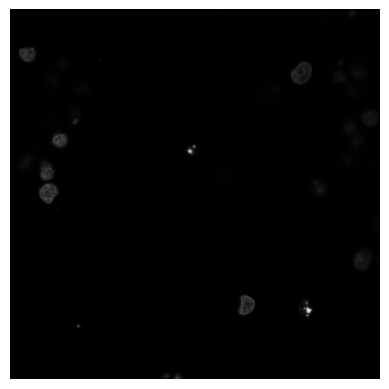

In [17]:
import tifffile
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

subset = samplesheet[
    (samplesheet['Row'] == 2) & 
    (samplesheet['Column'] == 11) & 
    (samplesheet['Frame'] == 20)]

print(subset)

nuc_path = subset[subset["Structure"] == "Nuclei"]["filepath"].iloc[0]
lyso_path = subset[subset["Structure"] == "Lysosome"]["filepath"].iloc[0]
mito_path = subset[subset["Structure"] == "Mitochondria"]["filepath"].iloc[0]
endo_path = subset[subset["Structure"] == "Endosome"]["filepath"].iloc[0]

nuc = tifffile.imread(nuc_path)
lyso = tifffile.imread(lyso_path)
mito = tifffile.imread(mito_path)
endo = tifffile.imread(endo_path)

radius_px = 120
fname = os.path.basename(experiment_name)

df = nuclei_features.copy()
df = nuclei_features[nuclei_features["image_name"] == fname]
ys = df["centroid-0"].astype(float)
xs = df["centroid-1"].astype(float)

# Display
fig, ax = plt.subplots()
ax.imshow(nuc, cmap="gray")
ax.axis("off")

# Draw circles only (no centroid dots)
for x, y in zip(xs, ys):
    circ = Circle((x, y), radius=radius_px, fill=False, edgecolor="red", linewidth=1.5)
    ax.add_patch(circ)

plt.show()


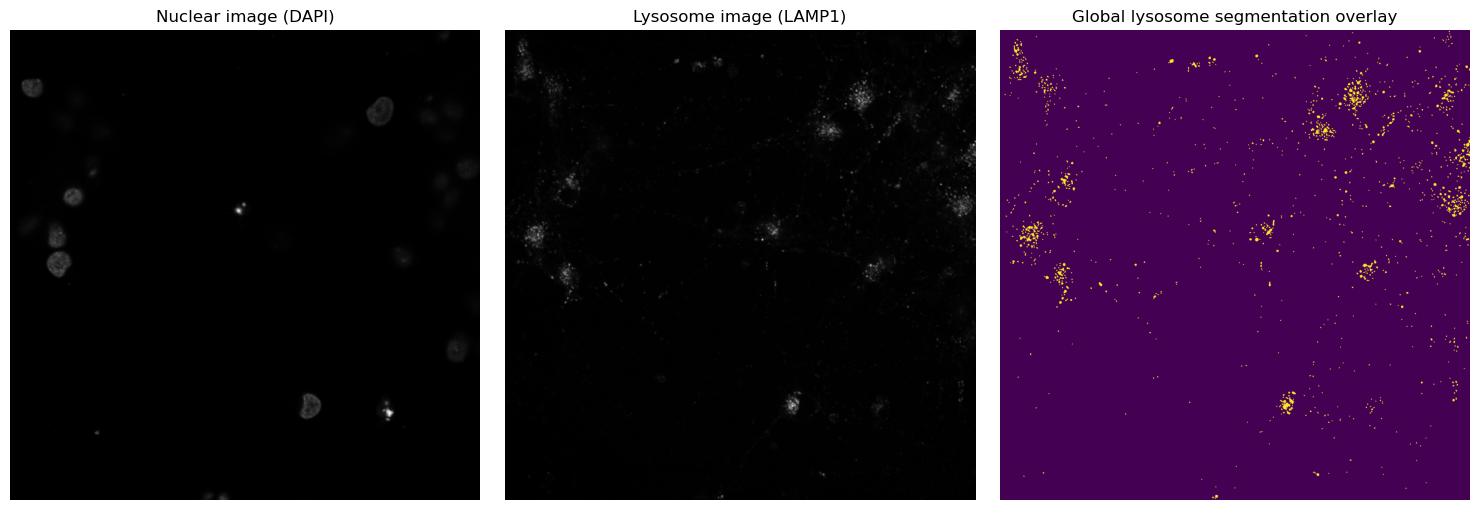

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

global_lys_seg = process_lysosome_mask(lyso)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def draw_circles(ax):
    for y, x in zip(ys, xs):
        circ = Circle((x, y), radius=radius_px, fill=False, edgecolor="red", linewidth=1)
        ax.add_patch(circ)

# --- 1. Nuclear image ---
axes[0].imshow(nuc, cmap="gray")
axes[0].set_title("Nuclear image (DAPI)")
axes[0].axis("off")
draw_circles(axes[0])

# --- 2. Lysosome image ---
axes[1].imshow(lyso, cmap="gray")
axes[1].set_title("Lysosome image (LAMP1)")
axes[1].axis("off")
draw_circles(axes[1])

# --- 3. Lysosome segmentation overlay ---
axes[2].imshow(global_lys_seg)
axes[2].set_title("Global lysosome segmentation overlay")
axes[2].axis("off")
draw_circles(axes[2])

plt.tight_layout()
plt.show()

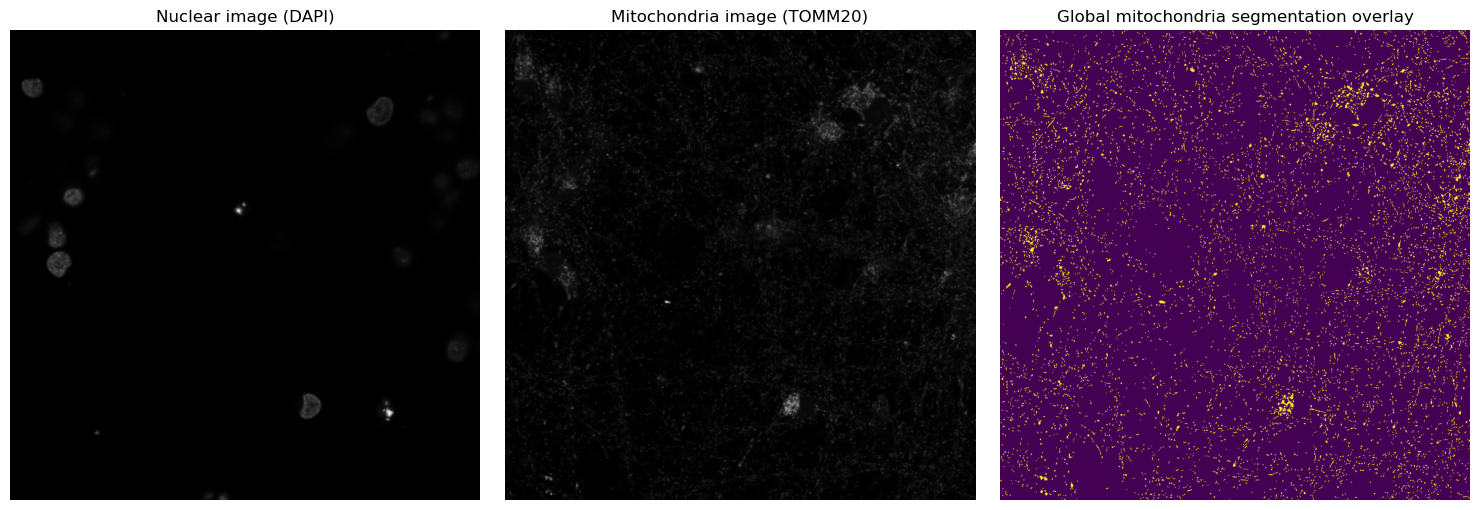

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

global_mito_seg = process_mitochondria_mask(mito)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def draw_circles(ax):
    for y, x in zip(ys, xs):
        circ = Circle((x, y), radius=radius_px, fill=False, edgecolor="red", linewidth=1)
        ax.add_patch(circ)

# --- 1. Nuclear image ---
axes[0].imshow(nuc, cmap="gray")
axes[0].set_title("Nuclear image (DAPI)")
axes[0].axis("off")
draw_circles(axes[0])

# --- 2. Mitochondria image ---
axes[1].imshow(mito, cmap="gray")
axes[1].set_title("Mitochondria image (TOMM20)")
axes[1].axis("off")
draw_circles(axes[1])

# --- 3. Mitochondria segmentation overlay ---
axes[2].imshow(global_mito_seg)
axes[2].set_title("Global mitochondria segmentation overlay")
axes[2].axis("off")
draw_circles(axes[2])

plt.tight_layout()
plt.show()

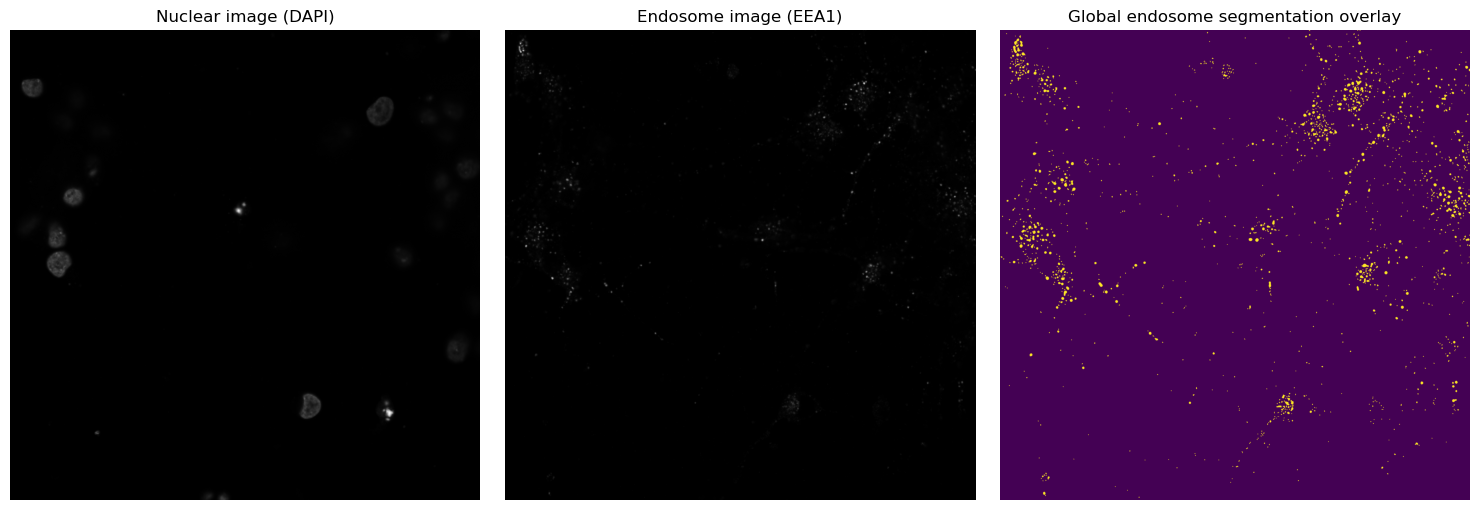

In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

global_endo_seg = process_mitochondria_mask(endo)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def draw_circles(ax):
    for y, x in zip(ys, xs):
        circ = Circle((x, y), radius=radius_px, fill=False, edgecolor="red", linewidth=1)
        ax.add_patch(circ)

# --- 1. Nuclear image ---
axes[0].imshow(nuc, cmap="gray")
axes[0].set_title("Nuclear image (DAPI)")
axes[0].axis("off")
draw_circles(axes[0])

# --- 2. Endosome image ---
axes[1].imshow(endo, cmap="gray")
axes[1].set_title("Endosome image (EEA1)")
axes[1].axis("off")
draw_circles(axes[1])

# --- 3. Endosome segmentation overlay ---
axes[2].imshow(global_endo_seg)
axes[2].set_title("Global endosome segmentation overlay")
axes[2].axis("off")
draw_circles(axes[2])

plt.tight_layout()
plt.show()

In [21]:
import os
import re
import uuid
import numpy as np
import pandas as pd
import tifffile
import dask.array as da
import dask
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from skimage.measure import label
from concurrent.futures import ProcessPoolExecutor, as_completed
from scipy.stats import norm
from scipy.ndimage import distance_transform_edt, gaussian_laplace, binary_fill_holes
from skimage import filters, morphology
from skimage.filters import threshold_triangle, threshold_otsu
from skimage.morphology import remove_small_objects, erosion, dilation
from skimage.morphology import disk as morph_disk

# =========================
# SEGMENTERS
# =========================

def process_golgi_mask(image, intensity_scaling_param=[9, 19], blur_sigma=1,
                       log_sigma=1.6, log_cutoff=0.02, low_thresh_minArea=1200,
                       minArea=10, thin_dist=1):
    m, s = norm.fit(image)
    stretch_min = max(m - intensity_scaling_param[0] * s, image.min())
    stretch_max = min(m + intensity_scaling_param[1] * s, image.max())
    image_norm = (np.clip(image, stretch_min, stretch_max) - stretch_min) / (stretch_max - stretch_min + 1e-12)
    blurred = filters.gaussian(image_norm, sigma=blur_sigma)
    thresh = threshold_triangle(blurred)
    img_low_thresh = remove_small_objects(blurred > thresh, min_size=low_thresh_minArea, connectivity=1)
    img_low_thresh = dilation(img_low_thresh, footprint=morph_disk(2))
    img_high_thresh = np.zeros_like(img_low_thresh)
    lab_low, num_obj = label(img_low_thresh, return_num=True, connectivity=1)
    for idx in range(num_obj):
        single_obj = lab_low == (idx + 1)
        local_otsu = threshold_otsu(blurred[single_obj > 0])
        img_high_thresh[np.logical_and(blurred > local_otsu * 0.98, single_obj)] = 1
    skeleton = morphology.medial_axis(img_high_thresh > 0)
    dist = distance_transform_edt(skeleton == 0)
    mask = dist > 1 + 1e-5
    thinned = np.logical_xor(img_high_thresh > 0, erosion(img_high_thresh > 0, morph_disk(thin_dist)))
    skele_mask = np.where(np.logical_and(mask, thinned), 0, img_high_thresh)
    log = -1 * (log_sigma**2) * gaussian_laplace(blurred, sigma=log_sigma)
    golgi_mask = remove_small_objects(np.logical_or(log > log_cutoff, skele_mask) > 0, min_size=minArea, connectivity=1)
    return binary_fill_holes(golgi_mask)


def process_lysosome_mask(image, intensity_scaling_param=[3, 19], blur_sigma=1,
                          log_params=((5.0, 0.09), (2.5, 0.07), (1.0, 0.01)),
                          vesselness_sigma=[1], vesselness_cutoff=0.15, min_area=15):
    m, s = norm.fit(image.ravel())
    stretch_min = max(m - intensity_scaling_param[0] * s, image.min())
    stretch_max = min(m + intensity_scaling_param[1] * s, image.max())
    image_norm = (np.clip(image, stretch_min, stretch_max) - stretch_min) / (stretch_max - stretch_min + 1e-12)
    blurred = filters.gaussian(image_norm, sigma=blur_sigma)
    log_mask = np.logical_or.reduce([(-1.0 * sig**2 * gaussian_laplace(blurred, sigma=sig)) > cut for sig, cut in log_params])
    vessel_mask = filters.frangi(blurred, sigmas=vesselness_sigma) > vesselness_cutoff
    return remove_small_objects(binary_fill_holes(np.logical_or(log_mask, vessel_mask)), min_size=min_area, connectivity=1)


def process_endosome_mask(image, intensity_scaling_param=[3, 19], blur_sigma=1.0,
                          log_params=((1.0, 0.03),), min_area=3):
    m, s = norm.fit(image.ravel())
    stretch_min = max(m - intensity_scaling_param[0] * s, image.min())
    stretch_max = min(m + intensity_scaling_param[1] * s, image.max())
    image_norm = (np.clip(image, stretch_min, stretch_max) - stretch_min) / (stretch_max - stretch_min + 1e-12)
    blurred = filters.gaussian(image_norm, sigma=blur_sigma)
    log_mask = np.logical_or.reduce([(-1.0 * sig**2 * gaussian_laplace(blurred, sigma=sig)) > cut for sig, cut in log_params])
    return remove_small_objects(binary_fill_holes(log_mask), min_size=min_area, connectivity=1)


def process_mitochondria_mask(image, intensity_scaling_param=[3.5, 15], blur_sigma=1.0,
                              log_params=((5.0, 0.09), (2.5, 0.07), (1.0, 0.01)),
                              vesselness_sigmas=(1.5,), vesselness_cutoff=0.16,
                              black_ridges=False, min_area=10, fill_holes=False):
    m, s = norm.fit(image.ravel())
    stretch_min = max(m - intensity_scaling_param[0] * s, image.min())
    stretch_max = min(m + intensity_scaling_param[1] * s, image.max())
    image_norm = (np.clip(image, stretch_min, stretch_max) - stretch_min) / (stretch_max - stretch_min + 1e-12)
    blurred = filters.gaussian(image_norm, sigma=blur_sigma)
    log_mask = np.logical_or.reduce([(-1.0 * sig**2 * gaussian_laplace(blurred, sigma=sig)) > cut for sig, cut in log_params])
    vessel_mask = filters.frangi(blurred, sigmas=vesselness_sigmas, black_ridges=black_ridges) > vesselness_cutoff
    combined = np.logical_or(log_mask, vessel_mask)
    if fill_holes:
        combined = binary_fill_holes(combined)
    return remove_small_objects(combined, min_size=min_area, connectivity=1)


# =========================
# CONFIG
# =========================

SEGMENTERS_BY_STRUCTURE = {
    "Golgi":        process_golgi_mask,
    "Lysosome":     process_lysosome_mask,
    "Endosome":     process_endosome_mask,
    "Mitochondria": process_mitochondria_mask,
}
ALLOWED_STRUCTURES = set(SEGMENTERS_BY_STRUCTURE.keys())

ROI_RADIUS  = 120
N_WORKERS   = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count()))
SITE_KEYS   = ["subdirectory", "Row", "Column", "Frame", "Plane", "Time"]

# --- QC controls ---
SHOW_QC                 = True
QC_MAX_SITES            = 5
QC_MAX_TILES_PER_STRUCT = 8
QC_OUTPUT_DIR           = "./qc_figures"


# =========================
# HELPERS
# =========================

_site_re = re.compile(
    r"r(?P<Row>\d+)c(?P<Column>\d+)f(?P<Frame>\d+)p(?P<Plane>\d+)"
    r"-ch(?P<ChannelID>\d+)t(?P<Time>\d+)", re.IGNORECASE)

def parse_site_keys_from_filename(fname: str) -> dict:
    m = _site_re.search(str(fname))
    if not m:
        return {}
    d = m.groupdict()
    out = {k: d[k] for k in ("Row", "Column", "Frame", "Plane", "Time") if d.get(k)}
    out["subdirectory"] = f"r{out['Row'].zfill(2)}c{out['Column'].zfill(2)}"
    return out

def imread_plane(path, prefer_lazy=True, enforce_2d=True):
    with tifffile.TiffFile(path) as tf:
        page = tf.pages[0]
        shape = page.shape if page.ndim <= 2 else tuple(page.shape[1:])
        dtype = page.dtype
    if not prefer_lazy:
        arr = tifffile.imread(path)
        if enforce_2d and arr.ndim == 3 and arr.shape[0] == 1:
            arr = arr[0]
        return arr

    @dask.delayed
    def _read(path_):
        arr = tifffile.imread(path_)
        if arr.ndim == 3 and arr.shape[0] == 1:
            arr = arr[0]
        return arr

    return da.from_delayed(_read(path), shape=shape, dtype=dtype)

def bbox_from_center(y, x, r, H, W):
    yi, xi = int(round(y)), int(round(x))
    return max(yi - r, 0), min(yi + r + 1, H), max(xi - r, 0), min(xi + r + 1, W)

def get_row(site_df: pd.DataFrame, **filters):
    sel = site_df.copy()
    for k, v in filters.items():
        sel = sel[sel[k] == v]
    return None if sel.empty else sel.iloc[0]

def _draw_circles(ax, xs, ys, r):
    for y, x in zip(ys, xs):
        ax.add_patch(Circle((x, y), r, fill=False, edgecolor="red", linewidth=1))

def qc_show_three_panel(nuc_img, ch_img, global_seg, xs, ys, r, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(nuc_img, cmap="gray"); axes[0].set_title(f"{title_prefix} – DAPI");    axes[0].axis("off")
    axes[1].imshow(ch_img,  cmap="gray"); axes[1].set_title(f"{title_prefix} – Channel"); axes[1].axis("off")
    axes[2].imshow(ch_img,  cmap="gray"); axes[2].imshow(global_seg, alpha=0.4)
    axes[2].set_title(f"{title_prefix} – Overlay"); axes[2].axis("off")
    for ax in axes:
        _draw_circles(ax, xs, ys, r)
    plt.tight_layout()
    plt.show()

def qc_tile_gallery(ch_img, tiles, seg_tiles, title_prefix, max_tiles=8):
    if max_tiles <= 0 or len(tiles) == 0:
        return
    n = min(max_tiles, len(tiles))
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]
    for ax, (tile, seg) in zip(axes, list(zip(tiles, seg_tiles))[:n]):
        ax.imshow(tile, cmap="gray"); ax.imshow(seg, alpha=0.4); ax.axis("off")
    fig.suptitle(f"{title_prefix} – example ROI tiles", y=1.02)
    plt.tight_layout()
    plt.show()

def _write_site_parquet(df, base_dir, mid, dapi_name):
    os.makedirs(base_dir, exist_ok=True)
    uid   = uuid.uuid4().hex[:8]
    mid_s  = str(mid).replace("/", "_")
    dapi_s = str(dapi_name).replace("/", "_")
    out_path = os.path.join(base_dir, f"MID={mid_s}__DAPI={dapi_s}__{uid}.parquet")
    df.to_parquet(out_path, index=False)
    return out_path


# =========================
# CORE: process_site
# =========================

def process_site(site_meta, site_df, nuclei_features, segmenters_by_structure,
                 r=ROI_RADIUS, do_qc=False):
    site_df = site_df.copy()
    for c in ("Stain", "Structure", "filename"):
        if c in site_df.columns:
            site_df[c] = site_df[c].astype(str).str.strip()
    site_df["Stain"] = site_df["Stain"].str.upper()

    dapi_row = get_row(site_df, Stain="DAPI")
    if dapi_row is None:
        return None

    dapi_fname = str(dapi_row["filename"]).strip()
    nuc_da     = imread_plane(dapi_row["filepath"])
    H, W       = nuc_da.shape[:2]
    nuc_img    = np.asarray(nuc_da.compute()) if do_qc else None

    nf = nuclei_features.copy()
    key_col = "filename"   # renamed before entering worker
    nf[key_col] = nf[key_col].astype(str).str.strip()

    props_fname = str(site_meta.get("props_filename", site_meta.get("dapi_filename", ""))).strip()
    nf_sel = nf[nf[key_col] == props_fname]
    if nf_sel.empty:
        nf_sel = nf[nf[key_col] == dapi_fname]
    if nf_sel.empty:
        return None

    ys     = nf_sel["centroid-0"].astype(float).to_numpy()
    xs     = nf_sel["centroid-1"].astype(float).to_numpy()
    labels = nf_sel["label"].astype(int).to_numpy() if "label" in nf_sel.columns else np.arange(1, len(xs) + 1)

    canon  = {k.lower(): k for k in segmenters_by_structure}
    site_df["Structure"] = site_df["Structure"].str.lower().map(canon).fillna(site_df["Structure"])
    todo   = [s for s in sorted(set(site_df["Structure"].unique()) & set(segmenters_by_structure))
              if callable(segmenters_by_structure.get(s))]
    if not todo:
        return None

    out_rows = []
    for structure in todo:
        seg_fn = segmenters_by_structure[structure]
        row    = site_df.loc[site_df["Structure"] == structure].iloc[0]
        ch_da  = imread_plane(row["filepath"])
        if ch_da.shape[:2] != (H, W):
            raise ValueError(f"Shape mismatch @ {structure}: {ch_da.shape} vs {(H, W)}")

        global_seg                  = np.zeros((H, W), dtype=bool)
        example_tiles, example_segs = [], []

        for lab, y, x in zip(labels, ys, xs):
            y0, y1, x0, x1 = bbox_from_center(y, x, r, H, W)
            tile = np.asarray(ch_da[y0:y1, x0:x1].compute())
            yy, xx = np.ogrid[y0:y1, x0:x1]
            roi      = (yy - y)**2 + (xx - x)**2 <= r**2
            seg_tile = seg_fn(np.where(roi, tile, 0)) & roi
            global_seg[y0:y1, x0:x1] |= seg_tile

            if do_qc and len(example_tiles) < QC_MAX_TILES_PER_STRUCT:
                example_tiles.append(tile)
                example_segs.append(seg_tile)

            obj_labels = label(seg_tile, connectivity=1)
            count_obj  = int(obj_labels.max())
            vals       = tile[seg_tile]
            area_px    = int(seg_tile.sum())
            roi_area   = int(roi.sum())
            coverage_frac = (area_px / roi_area) if roi_area else 0.0
            area_px_mean  = (area_px / count_obj) if count_obj else 0.0

            if vals.size:
                int_max    = float(vals.max())
                int_sum    = float(vals.sum())
                int_mean   = float(vals.mean())
                int_median = float(np.median(vals))
                int_std    = float(vals.std())
            else:
                int_max = int_sum = 0.0
                int_mean = int_median = int_std = np.nan

            int_cv = (int_std / int_mean) if (not np.isnan(int_mean) and int_mean != 0) else np.nan

            rad      = np.sqrt((yy - y)**2 + (xx - x)**2)
            rad_norm = np.zeros_like(rad, dtype=float)
            rad_norm[roi] = rad[roi] / float(r)
            rad_obj  = rad_norm[seg_tile]
            rad_n    = rad_obj.size

            if rad_n:
                radial_mean         = float(rad_obj.mean())
                radial_p25          = float(np.percentile(rad_obj, 25))
                radial_p50          = float(np.percentile(rad_obj, 50))
                radial_p75          = float(np.percentile(rad_obj, 75))
                inner_frac          = float((rad_obj < 0.33).sum()) / rad_n
                mid_frac            = float(((rad_obj >= 0.33) & (rad_obj < 0.66)).sum()) / rad_n
                outer_frac          = float((rad_obj >= 0.66).sum()) / rad_n
                boundary_touch_frac = float(((r - rad[seg_tile]) <= 5).sum()) / rad_n
            else:
                radial_mean = radial_p25 = radial_p50 = radial_p75 = np.nan
                inner_frac  = mid_frac = outer_frac = boundary_touch_frac = 0.0

            out_rows.append({
                "Measurement_ID": site_meta.get("Measurement_ID"),
                "subdirectory": row.get("subdirectory"),
                "Row": row.get("Row"), "Column": row.get("Column"),
                "Frame": row.get("Frame"), "Plane": row.get("Plane"), "Time": row.get("Time"),
                "DAPI_filename": dapi_fname,
                "channel_filename": row["filename"],
                "Structure": structure,
                "Stain": row.get("Stain"),
                "Nucleus_ID": int(lab),
                "area_px": area_px,
                "coverage_frac": coverage_frac,
                "organelle_count": count_obj,
                "average_organelle_area": area_px_mean,
                "max_f_intensity": int_max,
                "sum_f_intensity": int_sum,
                "mean_f_intensity": int_mean,
                "median_f_intensity": int_median,
                "CoefOfVar_intensity": int_cv,
                "radial_mean": radial_mean,
                "radial_p25": radial_p25, "radial_p50": radial_p50, "radial_p75": radial_p75,
                "inner_frac": inner_frac, "mid_frac": mid_frac, "outer_frac": outer_frac,
                "boundary_touch_frac": boundary_touch_frac,
            })

        if do_qc:
            ch_img = np.asarray(ch_da.compute())
            title  = f"{structure} | {dapi_fname}"
            qc_show_three_panel(nuc_img, ch_img, global_seg, xs, ys, r, title_prefix=title)
            if QC_MAX_TILES_PER_STRUCT > 0:
                qc_tile_gallery(ch_img, example_tiles, example_segs,
                                title_prefix=title, max_tiles=QC_MAX_TILES_PER_STRUCT)

    return pd.DataFrame(out_rows) if out_rows else None


# =========================
# SITE ITERATION
# samplesheet     → "filename"
# nuclei_features → "image_name"
# =========================

def iter_sites_single_panel(samplesheet, nuclei_features):
    ss = samplesheet.copy()
    ss["filename"] = ss["filename"].astype(str).str.strip()
    nf = nuclei_features.copy()
    nf["image_name"] = nf["image_name"].astype(str).str.strip()

    site_keys = ["Row", "Column", "Frame", "Plane", "Time"]

    for fname in nf["image_name"].unique():
        # Find the matching row for this filename
        matched = ss.loc[ss["filename"] == fname]
        if matched.empty:
            keys = parse_site_keys_from_filename(fname)
            if not keys:
                continue
            mask = np.ones(len(ss), dtype=bool)
            for k, v in keys.items():
                if k in ss.columns:
                    mask &= ss[k].astype(str).str.strip() == str(v).strip()
            matched = ss.loc[mask]

        if matched.empty:
            continue

        # Expand to ALL rows sharing the same site keys (all channels)
        row0 = matched.iloc[0]
        mask = np.ones(len(ss), dtype=bool)
        for k in site_keys:
            if k in ss.columns:
                mask &= ss[k].astype(str).str.strip() == str(row0[k]).strip()
        site_df = ss.loc[mask].copy()

        if site_df.empty:
            continue

        site_meta = {
            "Measurement_ID": site_df["Measurement_ID"].iloc[0] if "Measurement_ID" in site_df.columns else None,
            "dapi_filename": fname,
            "props_filename": fname,
        }
        yield site_meta, site_df


# =========================
# WORKER
# =========================

def _process_site_worker(args):
    site_meta, site_df, nuclei_features, r, do_qc, qc_output_dir, segmenters = args

    # process_site expects "filename" in nuclei_features
    nuclei_features = nuclei_features.copy().rename(columns={"image_name": "filename"})

    if do_qc:
        import matplotlib
        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
        os.makedirs(qc_output_dir, exist_ok=True)
        _orig_show = plt.show
        _site_id   = str(site_meta.get("dapi_filename", "site")).replace("/", "_")
        _fig_count = [0]

        def _save_instead(*a, **kw):
            fig  = plt.gcf()
            path = os.path.join(qc_output_dir, f"{_site_id}_fig{_fig_count[0]}.png")
            fig.savefig(path, bbox_inches="tight", dpi=100)
            plt.close(fig)
            _fig_count[0] += 1

        plt.show = _save_instead

    try:
        return process_site(site_meta, site_df, nuclei_features, segmenters, r=r, do_qc=do_qc)
    except Exception as e:
        print(f"[worker] {site_meta.get('dapi_filename')} failed: {e}")
        return None
    finally:
        if do_qc:
            plt.show = _orig_show


# =========================
# PARALLEL run_all
# =========================

def run_all_parallel(
    samplesheet, nuclei_features, segmenters_by_structure,
    r=ROI_RADIUS, n_workers=N_WORKERS, output_dir=None,
    show_qc=SHOW_QC, qc_max_sites=QC_MAX_SITES, qc_output_dir=QC_OUTPUT_DIR,
):
    samplesheet     = samplesheet.copy()
    nuclei_features = nuclei_features.copy()
    samplesheet["filename"]       = samplesheet["filename"].astype(str).str.strip()
    nuclei_features["image_name"] = nuclei_features["image_name"].astype(str).str.strip()

    all_sites = list(iter_sites_single_panel(samplesheet, nuclei_features))
    total     = len(all_sites)
    print(f"Found {total} sites — dispatching to {n_workers} workers")

    qc_count, args_list = 0, []
    for site_meta, site_df in all_sites:
        do_qc = show_qc and (qc_count < qc_max_sites)
        if do_qc:
            qc_count += 1
        args_list.append((site_meta, site_df, nuclei_features, r, do_qc, qc_output_dir, segmenters_by_structure))

    out, completed = [], 0

    with ProcessPoolExecutor(max_workers=n_workers) as pool:
        futures = {pool.submit(_process_site_worker, args): args[0] for args in args_list}
        for fut in as_completed(futures):
            site_meta  = futures[fut]
            completed += 1
            try:
                df = fut.result()
                if df is not None and not df.empty:
                    if output_dir:
                        _write_site_parquet(df, output_dir,
                                            site_meta.get("Measurement_ID", "unknown"),
                                            site_meta["dapi_filename"])
                    else:
                        out.append(df)
                    print(f"[{completed}/{total}] ✓ {site_meta['dapi_filename']} → {len(df)} rows")
                else:
                    print(f"[{completed}/{total}] – {site_meta['dapi_filename']} → no data")
            except Exception as e:
                print(f"[{completed}/{total}] ✗ {site_meta['dapi_filename']} → {e}")

    print("\nAll sites processed.")

    if output_dir:
        parts = [pd.read_parquet(os.path.join(output_dir, f))
                 for f in os.listdir(output_dir) if f.endswith(".parquet")]
        return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

In [ ]:
SHOW_QC = True
test_props = nuclei_features[nuclei_features["image_name"].str.contains("r02c11f20p01", regex=False)]

results_test = run_all_parallel(samplesheet, test_props, SEGMENTERS_BY_STRUCTURE, r=ROI_RADIUS, output_dir="./results_parquet")
results_test.head()

Found 1 sites — dispatching to 8 workers
[1/1] ✓ r02c11f20p01-ch01t01.tiff → 39 rows

All sites processed.


,Measurement_ID,subdirectory,Row,Column,Frame,Plane,Time,DAPI_filename,channel_filename,Structure,...,median_f_intensity,CoefOfVar_intensity,radial_mean,radial_p25,radial_p50,radial_p75,inner_frac,mid_frac,outer_frac,boundary_touch_frac
0,028ebee9-afaf-4ff8-b435-af11714285dc,r02c11,2,11,20,1,1,r02c11f20p01-ch01t01.tiff,r02c11f20p01-ch04t01.tiff,Endosome,...,9078.0,0.392655,0.786757,0.705652,0.812709,0.919734,0.000000,0.232984,0.767016,0.196335
1,028ebee9-afaf-4ff8-b435-af11714285dc,r02c11,2,11,20,1,1,r02c11f20p01-ch01t01.tiff,r02c11f20p01-ch04t01.tiff,Endosome,...,11251.0,0.397803,0.821903,0.746633,0.862107,0.930032,0.000000,0.188235,0.811765,0.127731
2,028ebee9-afaf-4ff8-b435-af11714285dc,r02c11,2,11,20,1,1,r02c11f20p01-ch01t01.tiff,r02c11f20p01-ch04t01.tiff,Endosome,...,6827.0,0.437615,0.717385,0.480225,0.793110,0.963248,0.139942,0.256560,0.603499,0.282799
3,028ebee9-afaf-4ff8-b435-af11714285dc,r02c11,2,11,20,1,1,r02c11f20p01-ch01t01.tiff,r02c11f20p01-ch04t01.tiff,Endosome,...,8209.5,0.405346,0.746815,0.631558,0.821802,0.963787,0.212598,0.039370,0.748031,0.295276
4,028ebee9-afaf-4ff8-b435-af11714285dc,r02c11,2,11,20,1,1,r02c11f20p01-ch01t01.tiff,r02c11f20p01-ch04t01.tiff,Endosome,...,11185.5,0.397223,0.730697,0.435266,0.775287,0.941251,0.044118,0.261029,0.694853,0.117647
